# 04 — BG on the Müller-Brown potential

The Müller-Brown potential is the canonical 2D benchmark for rare-event sampling: **3 minima** of different depth connected by 2 saddles. MCMC trapped in the deepest basin requires extremely long chains to discover the others.

We test if a BG can find and weigh the 3 minima correctly.


In [1]:
import torch, numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import trange
from bg.flows import RealNVP, GaussianPrior, FlowModel
from bg.energies import MullerBrown
from bg.losses import kl_by_example, kl_by_energy
from bg.sampling import sample_with_weights, effective_sample_size, normalized_weights

torch.manual_seed(0); np.random.seed(0)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)

mps


/Users/manumartinm/Documents/proyectos/boltzmann_generators/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Landscape

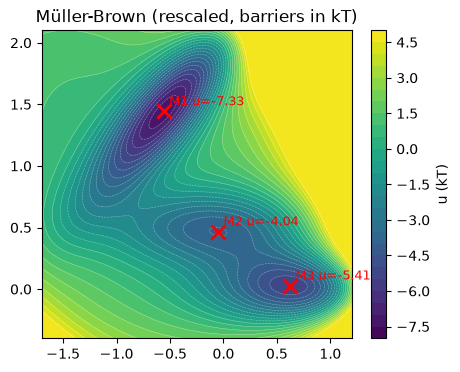

In [2]:
mb = MullerBrown(scale=20.0)
gx, gy, U = mb.grid(n=300)
fig, ax = plt.subplots(figsize=(5, 4))
levels = np.linspace(-8, 5, 27)
cs = ax.contourf(gx.numpy(), gy.numpy(), U.numpy().clip(max=5), levels=levels, cmap='viridis')
ax.contour(gx.numpy(), gy.numpy(), U.numpy().clip(max=5), levels=levels, colors='white', alpha=0.4, linewidths=0.4)
# annotate minima
minima = torch.tensor([[-0.558, 1.442], [-0.050, 0.467], [0.623, 0.028]])
for i, m in enumerate(minima):
    e = mb(m.unsqueeze(0)).item()
    ax.plot(m[0], m[1], 'rx', markersize=10, mew=2)
    ax.annotate(f'M{i+1} u={e:.2f}', (m[0]+0.05, m[1]+0.05), color='red', fontsize=9)
plt.colorbar(cs, ax=ax, label='u (kT)')
ax.set_title('Müller-Brown (rescaled, barriers in kT)')
plt.show()

## 2. MCMC from a single chain (will mostly stay in deepest well)

acc: 62.53%


acc: 57.69%


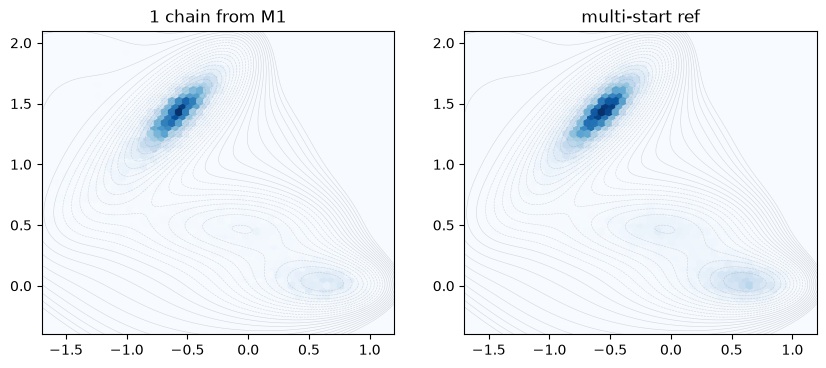

In [3]:
def mcmc(energy_fn, n_steps, x0, sigma=0.1, n_chains=1):
    x = x0.clone(); u = energy_fn(x); samples = torch.empty(n_steps, n_chains, 2); acc = 0
    for t in range(n_steps):
        xn = x + sigma * torch.randn_like(x); un = energy_fn(xn)
        a = torch.rand(n_chains) < torch.exp(-(un - u))
        x = torch.where(a[:, None], xn, x); u = torch.where(a, un, u); acc += a.sum().item()
        samples[t] = x
    print(f'acc: {acc / (n_steps*n_chains):.2%}')
    return samples.reshape(-1, 2)

# 1-chain MCMC from M1 (top-left, deepest)
short_mcmc = mcmc(mb, 30_000, x0=torch.tensor([[-0.55, 1.44]]), sigma=0.1)
# multi-chain MCMC for fair reference
n_chains = 24
x0 = torch.zeros(n_chains, 2)
x0[:8] = minima[0]; x0[8:16] = minima[1]; x0[16:] = minima[2]
long_mcmc = mcmc(mb, 4000, x0=x0, sigma=0.12, n_chains=n_chains)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, samp, title in zip(axes, [short_mcmc, long_mcmc], ['1 chain from M1', 'multi-start ref']):
    ax.contour(gx.numpy(), gy.numpy(), U.numpy().clip(max=5), levels=levels, colors='gray', alpha=0.3, linewidths=0.4)
    ax.hexbin(samp[:, 0], samp[:, 1], gridsize=50, cmap='Blues', extent=(-1.7, 1.2, -0.4, 2.1))
    ax.set_title(title); ax.set_aspect('equal')
plt.show()

## 3. BG: train with ML pretrain on multi-start data + KL_z fine-tune

Note: pure KL_z from a Gaussian prior fails badly on Müller-Brown — it collapses to one well. The paper's recipe (ML pretrain → mixed KL_z + KL_x) is essential.

#params: 208,944


ML pretrain:   0%|          | 0/2000 [00:00<?, ?it/s]

ML pretrain:   0%|          | 1/2000 [00:01<55:34,  1.67s/it]

ML pretrain:   0%|          | 5/2000 [00:01<08:59,  3.70it/s]

ML pretrain:   0%|          | 9/2000 [00:01<04:38,  7.15it/s]

...

mixed KL:  99%|█████████▉| 2981/3000 [01:27<00:00, 42.56it/s]

mixed KL: 100%|█████████▉| 2986/3000 [01:27<00:00, 42.56it/s]

mixed KL: 100%|█████████▉| 2991/3000 [01:28<00:00, 43.01it/s]

mixed KL: 100%|█████████▉| 2996/3000 [01:28<00:00, 43.41it/s]

mixed KL: 100%|██████████| 3000/3000 [01:28<00:00, 34.00it/s]

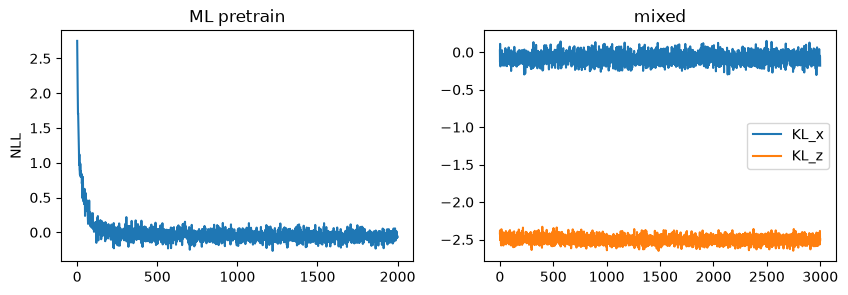

In [4]:
flow = RealNVP(dim=2, num_layers=12, hidden_dim=128, num_hidden=2, mask='halves', scale_clip=3.0)
model = FlowModel(GaussianPrior(2), flow).to(device)
print(f'#params: {sum(p.numel() for p in model.parameters()):,}')

x_data = long_mcmc.to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
hist = {'ml': [], 'mixed': []}

# Phase 1: pure ML
for step in trange(2000, desc='ML pretrain'):
    idx = torch.randint(0, x_data.shape[0], (512,), device=device)
    loss = kl_by_example(model, x_data[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    hist['ml'].append(loss.item())

# Phase 2: mixed
opt = torch.optim.Adam(model.parameters(), lr=3e-4)
w_kl = 0.0
for step in trange(3000, desc='mixed KL'):
    w_kl = min(1.0, step / 1000)  # ramp KL_z weight
    idx = torch.randint(0, x_data.shape[0], (512,), device=device)
    l_ml = kl_by_example(model, x_data[idx])
    l_kl = kl_by_energy(model, mb, 512, device=device, energy_max=30.0)
    loss = l_ml + w_kl * l_kl
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    opt.step()
    hist['mixed'].append((l_ml.item(), l_kl.item()))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(hist['ml']); axes[0].set_title('ML pretrain'); axes[0].set_ylabel('NLL')
ml, kl = zip(*hist['mixed'])
axes[1].plot(ml, label='KL_x'); axes[1].plot(kl, label='KL_z'); axes[1].set_title('mixed')
axes[1].legend()
plt.show()

## 4. Reweighted samples + populations of the 3 minima

ESS = 28884.6 / 30000 = 96.28%


     basin  u_min (kT)    true %      BG %  MCMC %
  M1 (top)   -7.334974 80.370003 80.230003   70.43
  M2 (mid)   -4.038387  7.740000  7.710000   11.82
M3 (right)   -5.408334 11.890000 12.050000   17.75


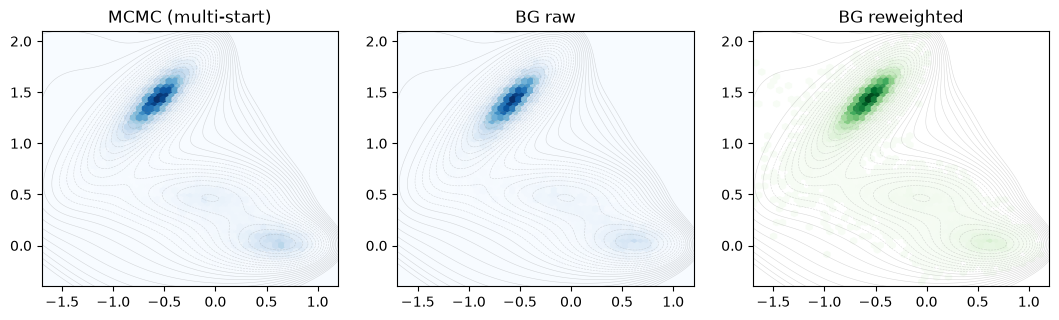

In [5]:
x_model, log_w, log_q = sample_with_weights(model, mb, n=30_000, device=device)
ess = effective_sample_size(log_w)
print(f'ESS = {ess:.1f} / 30000 = {ess/300:.2f}%')

# basin assignment by nearest minimum
def assign_basin(samples, minima):
    d = ((samples[:, None, :] - minima[None]) ** 2).sum(-1)
    return d.argmin(dim=-1)

w = normalized_weights(log_w)
basin_idx = assign_basin(x_model, minima)
pop_bg = torch.zeros(3)
for k in range(3):
    pop_bg[k] = w[basin_idx == k].sum()

# ground truth via long MCMC
basin_mcmc = assign_basin(long_mcmc, minima)
pop_mcmc = torch.bincount(basin_mcmc, minlength=3).float() / len(long_mcmc)

# also true via numerical integration on the grid (Z_k / Z_total)
gx_f, gy_f = gx.flatten(), gy.flatten()
grid_pts = torch.stack([gx_f, gy_f], dim=-1)
u_grid = mb(grid_pts)
w_grid = torch.exp(-u_grid - u_grid.min())  # shift for stability
basin_grid = assign_basin(grid_pts, minima)
pop_true = torch.zeros(3)
for k in range(3):
    pop_true[k] = w_grid[basin_grid == k].sum()
pop_true = pop_true / pop_true.sum()

import pandas as pd
df = pd.DataFrame({
    'basin': ['M1 (top)', 'M2 (mid)', 'M3 (right)'],
    'u_min (kT)': [mb(m.unsqueeze(0)).item() for m in minima],
    'true %': (pop_true*100).numpy().round(2),
    'BG %': (pop_bg*100).numpy().round(2),
    'MCMC %': (pop_mcmc*100).numpy().round(2),
})
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, samp, w_arr, title in zip(
    axes,
    [long_mcmc, x_model, x_model],
    [None, None, w.numpy()],
    ['MCMC (multi-start)', 'BG raw', 'BG reweighted'],
):
    ax.contour(gx.numpy(), gy.numpy(), U.numpy().clip(max=5), levels=levels, colors='gray', alpha=0.3, linewidths=0.4)
    if w_arr is None:
        ax.hexbin(samp[:, 0], samp[:, 1], gridsize=50, cmap='Blues', extent=(-1.7, 1.2, -0.4, 2.1))
    else:
        ax.hexbin(samp[:, 0], samp[:, 1], C=w_arr, reduce_C_function=np.sum, gridsize=50, cmap='Greens', extent=(-1.7, 1.2, -0.4, 2.1))
    ax.set_title(title); ax.set_aspect('equal')
plt.show()

## 5. Verification

Expected:
- The reweighted populations match the numerical-integration ground truth within a few percent for the dominant basins.
- ESS is much smaller than in the double-well — Müller-Brown is harder. >5% is acceptable; >20% is good.
- BG samples cover all 3 basins (mode covering preserved by the ML pretrain).

Limitations exposed:
- M3 (right basin) has small population (~few %) and is reweighted from very few samples.
- Pure KL_z without pretrain collapses (try removing the ML phase to see).
- Increasing flow depth + slow KL_z ramp helps but eventually you need better priors / replica exchange to scale beyond toy 2D.

Next: M7 (cross-check vs the original repo's Fig2_Mueller notebook).